## データの前処理

In [13]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 回転とリサイズ
affine = transforms.RandomAffine([-30, 30], scale=(0.8, 1.2))
# シフト
shift = transforms.RandomAffine((0, 0), translate=(0.5, 0.5))
# 左右反転
flip = transforms.RandomHorizontalFlip(p=0.5)
# 一部を消去
erasing = transforms.RandomErasing(p=0.5)
# 平均値を0, 標準偏差を1にする
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))
to_tensor = transforms.ToTensor()

# ノイズなしの訓練データ
transform_train = transforms.Compose([to_tensor, normalize])
# 一部消去した訓練データ
transform_train_erasing = transforms.Compose([to_tensor, erasing, normalize])
# 複数のノイズをランダムで与えた訓練データ
transform_train_random = transforms.Compose([
    transforms.RandomApply([affine], p=0.5),
    transforms.RandomApply([shift], p=0.5),
    transforms.RandomApply([flip], p=0.5),
    to_tensor,
    transforms.RandomApply([erasing], p=0.5),
    normalize,
])

transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_train_erasing = CIFAR10("./data", train=True, download=True, transform=transform_train_erasing)
cifar10_train_random = CIFAR10("./data", train=True, download=True, transform=transform_train_random)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
train_loader_erasing = DataLoader(cifar10_train_erasing, batch_size=batch_size, shuffle=True)
train_loader_random = DataLoader(cifar10_train_random, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

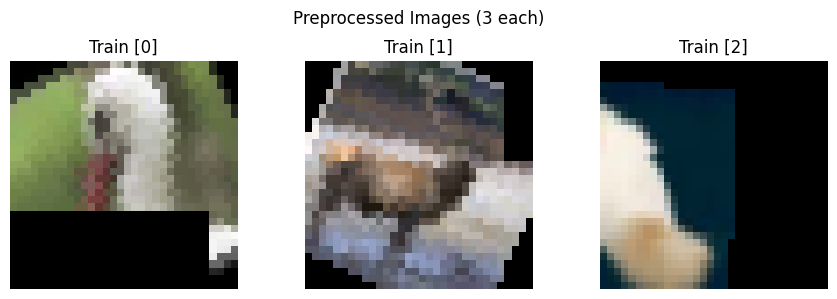

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i in range(3):
    img = next(iter(train_loader_random))[0][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f"Train [{i}]")
    axes[i].axis('off')

plt.suptitle("Preprocessed Images (3 each)")
plt.tight_layout()
plt.show()


## グラフ描画関数と学習率計算関数を定義

In [15]:
import matplotlib.pyplot as plt
import torch

def plot_loss_curve(record_loss_train, record_loss_test):
    plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
    plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.show()

def calculate_accuracy(net, data_loader, device="cuda", num_classes=10):
    # macro平均のprecision / recallを計算する
    tp_per_class = torch.zeros(num_classes, dtype=torch.long)
    fp_per_class = torch.zeros(num_classes, dtype=torch.long)
    fn_per_class = torch.zeros(num_classes, dtype=torch.long)

    correct = 0
    total = 0

    net.eval()
    with torch.no_grad():
        for _, (x, t) in enumerate(data_loader):
            x, t = x.to(device), t.to(device)
            y = net(x)
            pred = y.argmax(1)

            correct += (pred == t).sum().item()
            total += len(x)

            for c in range(num_classes):
                tp_per_class[c] += ((pred == c) & (t == c)).sum().cpu()
                fp_per_class[c] += ((pred == c) & (t != c)).sum().cpu()
                fn_per_class[c] += ((pred != c) & (t == c)).sum().cpu()

    accuracy = correct / total
    precision_per_class = tp_per_class.float() / (tp_per_class.float() + fp_per_class.float() + 1e-12)
    recall_per_class = tp_per_class.float() / (tp_per_class.float() + fn_per_class.float() + 1e-12)

    precision = precision_per_class.mean().item()
    recall = recall_per_class.mean().item()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }



## ベースライン③
- 複数のノイズをランダムで与えたデータセットで学習
- モデルはベースライン①と同じ
- 20エポック  
**→データセットが膨大なため、エポック数が足りなかった？**

In [16]:
import torch.nn as nn

class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 6, 5)
        # 活性化関数ReLU
        self.relu = nn.ReLU()
        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        # 畳み込み層
        self.conv2 = nn.Conv2d(6, 16, 5)
        # 全結合層
        self.fc1 = nn.Linear(16*5*5, 256)
        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)
        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    


In [17]:
# net初期化
net = Net1()
net.cuda() # GPU対応

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 2.031283176920908 Loss_Test: 1.7526831566148502
Epoch: 1 Loss_Train: 1.8736534121701174 Loss_Test: 1.6432577105844097
Epoch: 2 Loss_Train: 1.8160068949165247 Loss_Test: 1.5364998685326545
Epoch: 3 Loss_Train: 1.7774491829945303 Loss_Test: 1.488624995681131
Epoch: 4 Loss_Train: 1.7450422697969714 Loss_Test: 1.4710593496917919
Epoch: 5 Loss_Train: 1.720372159615197 Loss_Test: 1.4260335014124585
Epoch: 6 Loss_Train: 1.7092292115206609 Loss_Test: 1.407738461615933
Epoch: 7 Loss_Train: 1.6960709985259854 Loss_Test: 1.3679264700336822
Epoch: 8 Loss_Train: 1.6762169268734926 Loss_Test: 1.3854074090909048
Epoch: 9 Loss_Train: 1.6631372345378026 Loss_Test: 1.3547830619629782
Epoch: 10 Loss_Train: 1.6529961636914012 Loss_Test: 1.3442832565611336
Epoch: 11 Loss_Train: 1.6473700805088443 Loss_Test: 1.3043339715641775
Epoch: 12 Loss_Train: 1.637650927314368 Loss_Test: 1.296632194215325
Epoch: 13 Loss_Train: 1.6396592725878176 Loss_Test: 1.3263421954622694
Epoch: 14 Loss_Train: 

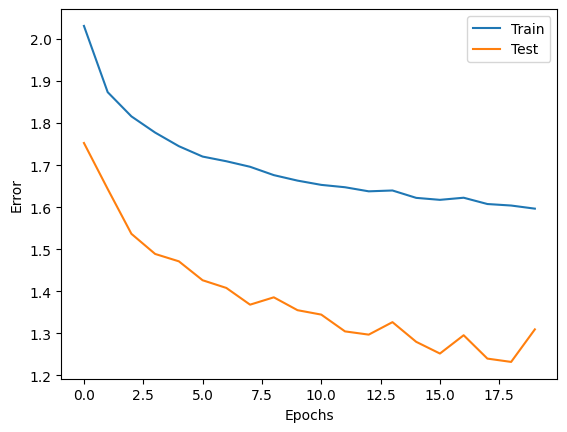

accuracy : 0.5390
precision: 0.5408
recall   : 0.5390


In [18]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
metrics = calculate_accuracy(net, test_loader, num_classes=10)
print(f"accuracy : {metrics['accuracy']:.4f}")
print(f"precision: {metrics['precision']:.4f}")
print(f"recall   : {metrics['recall']:.4f}")

## ベースライン④
- ベースライン③と同条件で、エポック数を40  
→精度はあまり変わらなかった

In [19]:
# net初期化
net = Net1()
net.cuda() # GPU対応

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(40): # 40エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 2.0197760418552875 Loss_Test: 1.7070298377116015
Epoch: 1 Loss_Train: 1.8683535282874046 Loss_Test: 1.5764234179903747
Epoch: 2 Loss_Train: 1.8116213889682995 Loss_Test: 1.53390760558426
Epoch: 3 Loss_Train: 1.7755974942765882 Loss_Test: 1.488672750770666
Epoch: 4 Loss_Train: 1.7498410546871097 Loss_Test: 1.4525123895353573
Epoch: 5 Loss_Train: 1.730789145392835 Loss_Test: 1.4027360692905013
Epoch: 6 Loss_Train: 1.717014082252522 Loss_Test: 1.3846017137454574
Epoch: 7 Loss_Train: 1.7070838537667414 Loss_Test: 1.3916776719366668
Epoch: 8 Loss_Train: 1.6992642348989502 Loss_Test: 1.3606068677962966
Epoch: 9 Loss_Train: 1.6850738403437389 Loss_Test: 1.3621134355569342
Epoch: 10 Loss_Train: 1.6858144100669705 Loss_Test: 1.3298359775239494
Epoch: 11 Loss_Train: 1.667928260458095 Loss_Test: 1.3485441617904954
Epoch: 12 Loss_Train: 1.6727693044316128 Loss_Test: 1.3280131611854407
Epoch: 13 Loss_Train: 1.6620306052515268 Loss_Test: 1.3288036767084888
Epoch: 14 Loss_Train: 

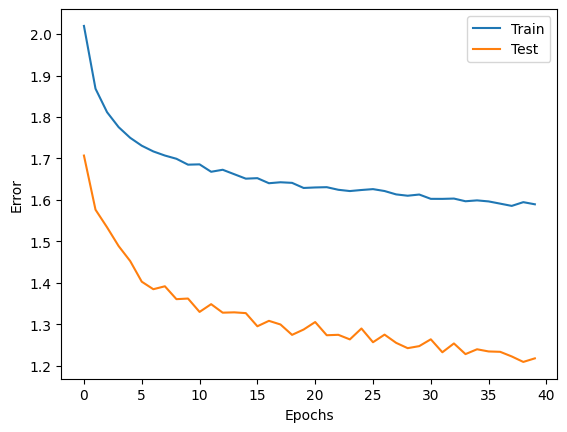

accuracy : 0.5676
precision: 0.5690
recall   : 0.5676


In [20]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
metrics = calculate_accuracy(net, test_loader, num_classes=10)
print(f"accuracy : {metrics['accuracy']:.4f}")
print(f"precision: {metrics['precision']:.4f}")
print(f"recall   : {metrics['recall']:.4f}")

## モデル検討③
- 複数のノイズをランダムで与えたデータセットで学習
- 40エポック
- Net2

In [21]:
import torch.nn as nn

class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [22]:
# net初期化
net = Net2()
net.cuda() # GPU対応


# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(40): # 40エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.9261478441755484 Loss_Test: 1.5955012550779208
Epoch: 1 Loss_Train: 1.7177640939002756 Loss_Test: 1.3553608276282147
Epoch: 2 Loss_Train: 1.6251024407194095 Loss_Test: 1.2635678265504777
Epoch: 3 Loss_Train: 1.568905413608112 Loss_Test: 1.1931714077664028
Epoch: 4 Loss_Train: 1.5232820091650003 Loss_Test: 1.1335008098820971
Epoch: 5 Loss_Train: 1.5049343127423844 Loss_Test: 1.1065955105101226
Epoch: 6 Loss_Train: 1.4719326627223999 Loss_Test: 1.0744818980526771
Epoch: 7 Loss_Train: 1.448418631425599 Loss_Test: 1.0299045120834545
Epoch: 8 Loss_Train: 1.4307130201698264 Loss_Test: 1.0715558517510724
Epoch: 9 Loss_Train: 1.4086625333637228 Loss_Test: 1.03375801614895
Epoch: 10 Loss_Train: 1.404240377190168 Loss_Test: 0.9706587347255391
Epoch: 11 Loss_Train: 1.3843608286679554 Loss_Test: 0.9628731509682479
Epoch: 12 Loss_Train: 1.3881585338841314 Loss_Test: 0.9434648410529848
Epoch: 13 Loss_Train: 1.3718992636331817 Loss_Test: 0.9352120692562905
Epoch: 14 Loss_Train:

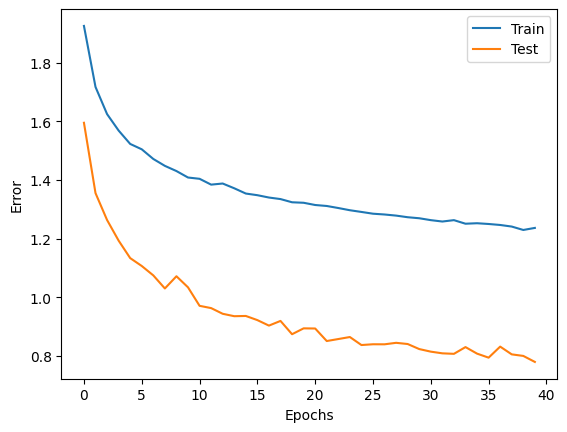

accuracy : 0.7298
precision: 0.7268
recall   : 0.7298


In [23]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
metrics = calculate_accuracy(net, test_loader, num_classes=10)
print(f"accuracy : {metrics['accuracy']:.4f}")
print(f"precision: {metrics['precision']:.4f}")
print(f"recall   : {metrics['recall']:.4f}")

## モデル検討④
- 

In [24]:
import torch.nn as nn

class Net3(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 実験結果まとめ

| 実験 | データ条件 | モデル条件 | エポック数 | 正解率 |
|---|---|---|---:|---:|
| ベースライン① | ノイズなし訓練データ（正規化のみ） | CNN（Conv: 3→6→16, カーネル5x5, FC: 16x5x5→256→10） | 20 | 61.97% |
| ベースライン② | 一部消去あり訓練データ（RandomErasing + 正規化） | ベースライン①と同一 | 20 | 60.69% |
| ベースライン③ | 複数ノイズをランダム付与した訓練データ | ベースライン①と同一 | 20 | 55.42% |
| ベースライン④ | 複数ノイズをランダム付与した訓練データ | ベースライン①と同一 | 40 | 57.26% |
| モデル検討① | 一部消去あり訓練データ | CNN改良（Conv: 3→32→64, カーネル3x3, FC: 64x6x6→256→10） | 20 | 71.21% |
| モデル検討② | 一部消去あり訓練データ | CNN改良（Conv: 3→32→64→128, プーリング回数増加, FC: 128x2x2→256→10） | 20 | 70.91% |
| モデル検討③ | 複数ノイズをランダム付与した訓練データ | CNN改良（Conv: 3→32→64, カーネル3x3, FC: 64x6x6→256→10） | 40 | 71.02% |
| モデル検討④ | 複数ノイズをランダム付与した訓練データ | CNN改良（Conv: 3→32→64→128, プーリング回数増加, FC: 128x2x2→256→10） | 20 | 68.90% |